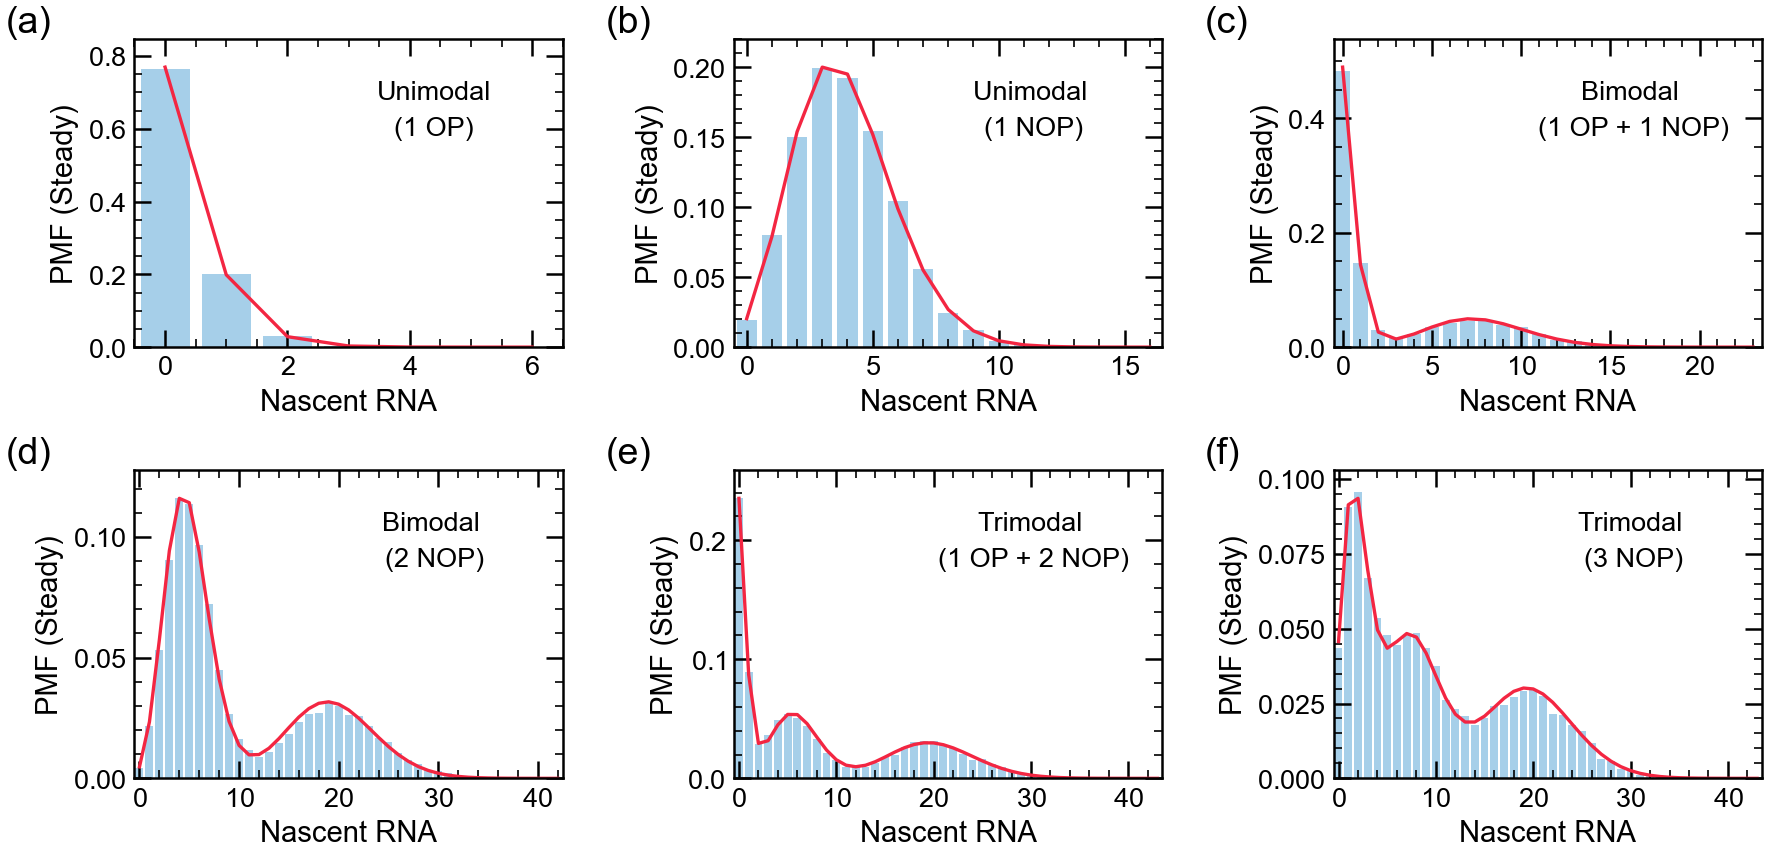

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.plot_style import configure_journal_style
from src.steady_state_theory import compute_limiting_pmf_and_moments
from src.lifetime_kernels import build_survival_funcs_from_shifted_two_exp
from src.utils import count_modes_from_pmf
from src.simulator import simulate_ensemble_N_grid

# ---------- Scenarios ----------
L = 6000.0

# (1) Zero-inflated unimodal: signature (1,0)
Q_A = np.array([[-2e-4, 1e-4, 1e-4],
                [ 1e-4,-2e-4, 1e-4],
                [ 1e-4, 1e-4,-2e-4]], float)
lam_A = np.array([0.001, 0.002, 0.001])     # small lambdas -> strong mass at n=0
W_A   = np.array([20.0, 20.0, 20.0])
v_A   = np.array([3000/60, 3000/60, 3000/60])  # 50 nt/s
T_A   = np.array([60.0, 60.0, 60.0])
H_A   = build_survival_funcs_from_shifted_two_exp(L=L, W_means=W_A, v_means=v_A, Tterm_means=T_A)

# (2) Unimodal (interior): signature (0,1)
Q_B = np.array([[-0.2, 0.1, 0.1],
                [ 0.1,-0.2, 0.1],
                [ 0.1, 0.1,-0.2]], float)    # fast switching -> averaging components
lam_B = np.array([0.020, 0.018, 0.022])
W_B   = np.array([15.0, 15.0, 15.0])
v_B   = np.array([3000/60, 3000/60, 3000/60])
T_B   = np.array([60.0, 60.0, 60.0])
H_B   = build_survival_funcs_from_shifted_two_exp(L=L, W_means=W_B, v_means=v_B, Tterm_means=T_B)

# (3) Bimodal (zero + one interior): signature (1,1)
Q_C = np.array([[-2e-4, 1e-4, 1e-4],
                [ 1e-4,-2e-4, 1e-4],
                [ 1e-4, 1e-4,-2e-4]], float)  # slow & symmetric -> ~equal pi
W_C = np.array([20.0, 20.0, 20.0])
v_C = np.array([3000/60, 3000/60, 3000/60])   # 50 nt/s -> L/v = 120 s
T_C = np.array([100.0, 100.0, 100.0])         # m ≈ 20 + 120 + 100 = 240 s
lam_C = np.array([0.001, 0.0015, 0.033], float)  # θ ≈ (0.24, 0.36, 7.92)
H_C = build_survival_funcs_from_shifted_two_exp(L=L, W_means=W_C, v_means=v_C, Tterm_means=T_C)

# (4) Bimodal (two interiors): signature (0,2)
Q_D = np.array([[-2e-4, 1e-4, 1e-4],
                [ 1e-4,-2e-4, 1e-4],
                [ 1e-4, 1e-4,-2e-4]], float)  # slow & symmetric
W_D = np.array([20.0, 20.0, 20.0])
v_D = np.array([3000/60, 3000/60, 3000/60])   # 50 nt/s -> L/v = 120 s
T_D = np.array([100.0, 100.0, 100.0])         # m ≈ 240 s
lam_D = np.array([0.0208, 0.083, 0.0208])     # θ ≈ (5, 19.9, 5) -> two interior modes
H_D = build_survival_funcs_from_shifted_two_exp(L=L, W_means=W_D, v_means=v_D, Tterm_means=T_D)

# (5) Trimodal: zero + two interiors: signature (1, 2)
Q_E = np.array([[-2e-5, 1e-5, 1e-5],
                [ 1e-5,-2e-5, 1e-5],
                [ 1e-5, 1e-5,-2e-5]], float)   # very slow & symmetric -> pi ≈ uniform
W_E = np.array([20.0, 20.0, 20.0])
v_E = np.array([3000/60, 3000/60, 3000/60])     # 50 nt/s -> L/v = 120 s
T_E = np.array([100.0, 100.0, 100.0])           # m ≈ 240 s for all states
lam_E = np.array([0.00146, 0.025, 0.0833], float)  # θ ≈ (0.35, 6.0, 20.0)
H_E = build_survival_funcs_from_shifted_two_exp(L=L, W_means=W_E, v_means=v_E, Tterm_means=T_E)

# (6) Trimodal (three interiors): signature (0,3)
Q_F = np.array([[-3e-5,  1.5e-5, 1.5e-5],
                [ 1.5e-5,-3e-5,  1.5e-5],
                [ 1.5e-5, 1.5e-5,-3e-5 ]], float)  # very slow & symmetric
lam_F = np.array([0.0083, 0.033, 0.083], float)
W_F   = np.array([20.0, 20.0, 20.0])
v_F   = np.array([3000/60, 3000/60, 3000/60])      # 50 nt/s -> L/v = 120 s
T_F   = np.array([100.0, 100.0, 100.0])            # m ≈ 240 s
H_F   = build_survival_funcs_from_shifted_two_exp(L=L, W_means=W_F, v_means=v_F, Tterm_means=T_F)
# θ ≈ (2.0, 7.9, 19.9) -> three interior modes expected

# Canonical scenarios for d = 3 (steady-state only; no simulation).
# Mode signature: (z, k) where z=1 if n=0 is a mode, and k is the number of non-zero modes.
scenarios = [
    ("Zero-inflated unimodal (1,0)",  Q_A, lam_A, H_A, W_A, v_A, T_A),
    ("Unimodal – interior (0,1)",     Q_B, lam_B, H_B, W_B, v_B, T_B),
    ("Bimodal – zero + one (1,1)",    Q_C, lam_C, H_C, W_C, v_C, T_C),
    ("Bimodal – two interiors (0,2)", Q_D, lam_D, H_D, W_D, v_D, T_D),
    ("Trimodal – zero + two (1,2)",   Q_E, lam_E, H_E, W_E, v_E, T_E),
    ("Trimodal – three interiors (0,3)", Q_F, lam_F, H_F, W_F, v_F, T_F),
]

Nmax = 150
configure_journal_style()


fig, axes = plt.subplots(2, 3, figsize=(7, 3.2))
axes = axes.ravel()  # Flatten the axes for easy indexing
for i, (title, Q, lam, H, W, v, T) in enumerate(scenarios):
    if i >= len(axes):  # If there are more scenarios than axes, break
        break
    ax = axes[i]
    # Simulation results
    R = 10000  # Number of simulation trajectories
    rng = np.random.default_rng(20251111)
    T_max=5000
    N_mat = simulate_ensemble_N_grid(Q, lam, L, W, v, T, T_max=5000, edges=np.linspace(0.0, T_max, 5001), R=R, pi0=None, rng=rng)

    Ns = N_mat[:, -1]                   
    maxN = int(max(Ns.max(), Nmax))
    bins = np.arange(0, maxN + 2) - 0.5
    hist, _ = np.histogram(Ns, bins=bins)
    emp_pmf = hist / max(hist.sum(), 1)
    ns = np.arange(0, maxN + 1)

    ax.bar(ns, emp_pmf, width=0.8, alpha=0.35, align="center",
           label="Simulation",color="#0277C0") 
    
    # Compute theoretical PMF and moments
    out = compute_limiting_pmf_and_moments(Q, lam, H, Nmax)
    # Robust unpacking
    if isinstance(out, tuple) and len(out) >= 1:
        p_n = np.asarray(out[0], float)
    elif isinstance(out, dict):
        p_n = np.asarray(out.get("p_n", out.get("pmf", out.get("p", None))), float)
    else:
        p_n = np.asarray(out, float)

    # Truncate tail
    cutoff = np.where(np.cumsum(p_n) > 0.999999)[0]
    maxN = int(cutoff[0]) if cutoff.size > 0 else len(p_n) - 1

    # Count modes and peaks
    k, peaks = count_modes_from_pmf(p_n[:maxN+1], prominence=1e-5, include_boundary=True)
    n = np.arange(maxN + 1)

    ax.plot(n, p_n[:maxN+1], linewidth=0.8, label="Theory",color="#F32642")
    # if peaks:
    #     ax.scatter(np.array(peaks), p_n[np.array(peaks)], s=5, label="Peaks",color="#F32642")
    
    ax.set_xlabel("Nascent RNA")
    ax.set_ylabel("PMF (Steady)")
    ax.set_xlim(-0.5, maxN + 0.5)
    ax.set_ylim(0.0, max(0.05, 1.1 * p_n[:maxN+1].max()))

# Add subplot labels
axes[0].text(-0.3, 1.00, '(a)', transform=axes[0].transAxes, fontsize=9, va='bottom', ha='left')
axes[1].text(-0.3, 1.00, '(b)', transform=axes[1].transAxes, fontsize=9, va='bottom', ha='left')
axes[2].text(-0.3, 1.00, '(c)', transform=axes[2].transAxes, fontsize=9, va='bottom', ha='left')
axes[3].text(-0.3, 1.00, '(d)', transform=axes[3].transAxes, fontsize=9, va='bottom', ha='left')
axes[4].text(-0.3, 1.00, '(e)', transform=axes[4].transAxes, fontsize=9, va='bottom', ha='left')
axes[5].text(-0.3, 1.00, '(f)', transform=axes[5].transAxes, fontsize=9, va='bottom', ha='left')

axes[0].text(0.7, 0.77, 'Unimodal\n(1 OP)', transform=axes[0].transAxes, fontsize=6.5, ha='center', va='center', linespacing=1.6  )
axes[1].text(0.7, 0.77, 'Unimodal \n(1 NOP)', transform=axes[1].transAxes, fontsize=6.5, ha='center', va='center', linespacing=1.6)
axes[2].text(0.7, 0.77, 'Bimodal \n(1 OP + 1 NOP)', transform=axes[2].transAxes, fontsize=6.5, ha='center', va='center', linespacing=1.6)
axes[3].text(0.7, 0.77, 'Bimodal \n(2 NOP)', transform=axes[3].transAxes, fontsize=6.5,ha='center', va='center', linespacing=1.6)
axes[4].text(0.7, 0.77, 'Trimodal \n(1 OP + 2 NOP)', transform=axes[4].transAxes, fontsize=6.5, ha='center', va='center', linespacing=1.6)
axes[5].text(0.7, 0.77, 'Trimodal \n(3 NOP)', transform=axes[5].transAxes, fontsize=6.5, ha='center', va='center', linespacing=1.6)

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.4)  # vertical and horizontal spacing
plt.savefig('Fig4.pdf', dpi=300, bbox_inches='tight')
plt.show()
